## Modules

In [1]:
import warnings
warnings.filterwarnings('ignore')
import random
import os

import numpy as np
import pandas as pd

import torch
from torch_geometric.utils import from_networkx
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.nn import Module
from torch import nn

import networkx as nx

from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from torch_geometric.utils import add_self_loops

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel, Word2Vec
from collections import defaultdict
from itertools import combinations

import json
import pickle

from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## 파일제목

In [2]:
k_num = 30
dim_num = 128
layer_num = 3
clusters_num = 120
epochs = 2000 #1500

# save file name
save_file_name = f'strong_weak_BERT_SentenTransf_word_embed_{epochs}'
save_or_not = False

## Data

In [ ]:
BERT_word_embed = pd.read_csv('/BERT_SentenTransf_word_embed.csv').rename(columns={'Unnamed: 0': 'word'}).set_index('word')

LDA_word_topic_prob = pd.read_csv('/LDA_word_topic_prob.csv').rename(columns={'Unnamed: 0': 'word'}).set_index('word')

In [4]:
# 원본 LDA 확률 행렬 (행=word, 열=topics)
sim_all = pd.DataFrame(cosine_similarity(LDA_word_topic_prob.values), index=LDA_word_topic_prob.index, columns=LDA_word_topic_prob.index)

### topic별로, 상위 단어들끼리의 연결관계 형성 및 집계

In [5]:
def unique_edges_from_topk(df: pd.DataFrame, k: int, topic_prefix: str = "LDA_Topic"):
    """
    df: index가 word, 컬럼이 LDA_Topic_* 인 DataFrame (질문 예시 형태)
        만약 'word' 컬럼이 있고 index가 아니라면 df = df.set_index('word') 후 사용
    k:   각 토픽별 상위 단어 개수
    topic_prefix: 토픽 컬럼 prefix (예: "LDA_Topic")
    """
    topic_cols = [c for c in df.columns if c.startswith(topic_prefix)]
    
    edge_set = set() # 중복 방지용
    edges = []
    
    for col in topic_cols:
        top_words = df[col].nlargest(k).index.tolist()
        for u, v in combinations(top_words, 2):
            key = tuple(sorted((u, v)))
            if key not in edge_set:
                edge_set.add(key)
                edges.append(key)
    
    return edges


def unique_edges_with_topics(df: pd.DataFrame, k: int, topic_prefix: str = "LDA_Topic"):
    topic_cols = [c for c in df.columns if c.startswith(topic_prefix)]
    
    edge_to_topics = {}
    
    for col in topic_cols:
        top_words = df[col].nlargest(k).index.tolist()
        for u, v in combinations(top_words, 2):
            key = tuple(sorted((u, v)))
            edge_to_topics.setdefault(key, []).append(col)
    

    edges_df = pd.DataFrame(
        [(u, v, edge_to_topics[(u, v)]) for (u, v) in edge_to_topics],
        columns=["source", "target", "topics"]
    )
    return edges_df

edges = unique_edges_from_topk(LDA_word_topic_prob, k_num)
edges_df = unique_edges_with_topics(LDA_word_topic_prob, k_num)
print(len(edges), "개 엣지") 
edges_df

10075 개 엣지


,source,target,topics
0,번역,영상,[LDA_Topic_0]
1,번역,음성,[LDA_Topic_0]
2,번역,텍스트,[LDA_Topic_0]
3,번역,제작,[LDA_Topic_0]
4,가능,번역,"[LDA_Topic_0, LDA_Topic_12]"
...,...,...,...
10070,인류,장관,[LDA_Topic_26]
10071,구사,인류,[LDA_Topic_26]
10072,부모,장관,[LDA_Topic_26]
10073,구사,부모,[LDA_Topic_26]


### 전체 값을 이용해 단어간 코사인 유사도를 계산하고, topic별 연결되는 상위 단어들에 해당하는 유사도만 채워넣기

In [6]:
# 1) 0으로 채운 새 DataFrame 생성 (index, columns 동일)
df3 = pd.DataFrame(0, index=sim_all.index, columns=sim_all.columns)

# 2) edge 리스트에 해당하는 값만 원래 값 복사
for u, v in edges:
    if u in sim_all.index and v in sim_all.columns:
        df3.at[u, v] = 1 #sim_all.at[u, v]
        df3.at[v, u] = 1 #sim_all.at[v, u]  # 무방향(대칭)

df3

word,개개인,개정,검토,경험,계획,고등학생,공유,과학,교과,교과서,...,홀맨,낚시,해양생물,사용률,기계번역,문자화,발화자,스트리트,버즈,애드테크
word,,,,,,,,,,,,,,,,,,,,,
개개인,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
개정,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
검토,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
경험,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
계획,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
문자화,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
발화자,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
스트리트,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
print((df3.values.diagonal() == 1).sum())

0


### Calculate Cosine Similarity

In [8]:
df1 = pd.concat([pd.DataFrame(BERT_word_embed.index), pd.DataFrame(cosine_similarity(BERT_word_embed))], axis=1).set_index('word')

df1.columns = df1.index
df3.columns = df3.index

# 단어 순서 섞어주기
words_shuffled = df1.index.tolist()
random.shuffle(words_shuffled)
# df1 = df1.loc[words_shuffled, words_shuffled]
df3 = df3.loc[words_shuffled, words_shuffled]
BERT_word_embed = BERT_word_embed.loc[words_shuffled]
# LDA_word_topic_prob = LDA_word_topic_prob.loc[words_shuffled]

# 음수 제거
# df1[df1 < 0] = 0
df3[df3 < 0] = 0

# # 두 단어 간 엣지 가중치 존재하면 연결 여부로 변환
# df3[df3 != 0] = 1

## Node Embedding / Edge Weight 지정

In [9]:
nod_embed = BERT_word_embed
edg_info = df3 

## 그래프 만들기


In [10]:
words = nod_embed.index.tolist()

edges = []
for i in range(len(words)):
    for j in range(i+1, len(words)):
        sim = edg_info.loc[words[i], words[j]]
        edges.append((words[i], words[j], sim))

edges_sorted = sorted(edges, key=lambda x: x[2], reverse=True)

G = nx.Graph()
for word in words:
    G.add_node(word, features=nod_embed.loc[word].values)

for u, v, w in edges_sorted:
    if w != 0:  # 0인 경우 연결 안 함
        G.add_edge(u, v, weight=w)


In [11]:
# --- 그래프 생성 완료 후 ---
isolated_nodes = list(nx.isolates(G))

print(f"고립 노드 개수(before fix): {len(isolated_nodes)}")

k_node = 1  # 고립 노드마다 최소 연결할 이웃 수
cosine_df = pd.DataFrame(sim_all, index=nod_embed.index, columns=nod_embed.index)

for node in isolated_nodes:
    if node not in cosine_df.index:
        continue
    # 자기 자신 제외한 모든 단어와 유사도 정렬 (낮은 순으로)
    neighbors = cosine_df.loc[node].drop(node).sort_values(ascending=False)
    # 0 이상인 값만 필터링
    valid_neighbors = neighbors[neighbors > 0]
    # 하위 k_node개 선택
    for neighbor, sim in valid_neighbors.head(k_node).items():
        if not G.has_edge(node, neighbor):
            G.add_edge(node, neighbor, weight=sim)

print(f"고립 노드 개수(after fix): {len(list(nx.isolates(G)))}")

고립 노드 개수(before fix): 2209
고립 노드 개수(after fix): 0


In [12]:
# 엣지 가중치별 개수 세기
edges_data = nx.get_edge_attributes(G, "weight")

count_eq_1 = sum(1 for w in edges_data.values() if w == 1)
count_lt_1 = sum(1 for w in edges_data.values() if 0 < w < 1)

print(f"가중치가 1인 엣지 개수: {count_eq_1}")
print(f"가중치가 1 미만인 엣지 개수: {count_lt_1}")


가중치가 1인 엣지 개수: 10075
가중치가 1 미만인 엣지 개수: 1885


In [13]:
def summarize_graph(G, weight_attr="weight"):
    n = G.number_of_nodes()
    m = G.number_of_edges()

    max_edges = n * (n - 1) / 2 if not G.is_directed() else n * (n - 1)

    density = nx.density(G)
    sparsity = 1.0 - density

    print(f"노드 수: {n}")
    print(f"엣지 수: {m}")
    print(f"최대 엣지 수: {int(max_edges)}")
    print(f"밀도(density): {density:.6f}")
    print(f"희소성(sparsity): {sparsity:.6f}")

    # --- 노드별 연결 개수 (degree) ---
    degrees = dict(G.degree())
    min_node = min(degrees, key=degrees.get)
    max_node = max(degrees, key=degrees.get)

    print(f"최소 degree: {degrees[min_node]} (노드: {min_node})")
    print(f"최대 degree: {degrees[max_node]} (노드: {max_node})")
    print(f"평균 degree: {np.mean(list(degrees.values())):.2f}")

    # --- 가중치 통계 ---
    weights = np.array(
        [d.get(weight_attr, np.nan) for _, _, d in G.edges(data=True)],
        dtype=float
    )
    weights = weights[~np.isnan(weights)]

    if weights.size == 0:
        print(f"'{weight_attr}' 속성이 있는 엣지가 없습니다.")
        return

    print(f"엣지 개수(가중치 있음): {weights.size}")
    print(f"최소 weight: {weights.min():.6f}")
    print(f"최대 weight: {weights.max():.6f}")
    print(f"평균 weight: {weights.mean():.6f}")
    print(f"중앙값 weight: {np.median(weights):.6f}")
    print(f"표준편차: {weights.std(ddof=0):.6f}")



summarize_graph(G, weight_attr="weight")

노드 수: 2597
엣지 수: 11960
최대 엣지 수: 3370906
밀도(density): 0.003548
희소성(sparsity): 0.996452
최소 degree: 1 (노드: 인수)
최대 degree: 215 (노드: 사용)
평균 degree: 9.21
엣지 개수(가중치 있음): 11960
최소 weight: 0.716999
최대 weight: 1.000000
평균 weight: 0.984548
중앙값 weight: 1.000000
표준편차: 0.044044


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'AppleGothic'   # Mac
plt.rcParams['axes.unicode_minus'] = False

[INFO] 사용된 시드: 302097
Component size: 956 nodes, 10643 edges

===== 결과 요약 =====
Seed used: 302097
Strong edges: 4
Weak edges: 3
Total edges: 7
Total nodes: 8

===== 선택된 엣지 상세 정보 (노드1, 노드2, weight, keyword1, keyword2) =====
 - Edge: (마음) — (이야기), weight=0.786923918473892
 - Edge: (생각) — (이야기), weight=1
 - Edge: (시작) — (이야기), weight=1
 - Edge: (시작) — (정도), weight=1
 - Edge: (시작) — (참석), weight=1
 - Edge: (대답) — (이야기), weight=0.8275962504622856
 - Edge: (특정) — (정도), weight=0.8588799985972874

Final subgraph: 8 nodes, 9 edges


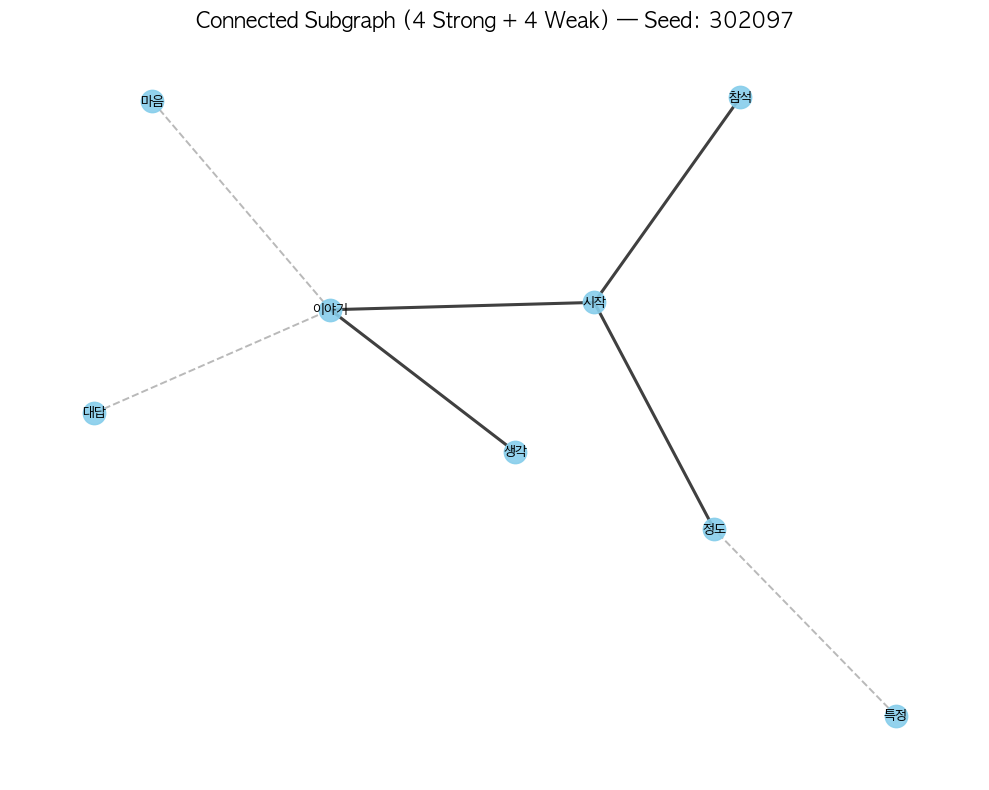

In [22]:
# -------------------------------
# 0. 시드를 자동으로 생성
# -------------------------------
SEED = 302097#random.randint(0, 999999)
print(f"[INFO] 사용된 시드: {SEED}")

random.seed(SEED)
np.random.seed(SEED)

# -------------------------------
# 1. 가장 큰 connected component 선택
# -------------------------------
components = list(nx.connected_components(G))
target_nodes = max(components, key=len)
target = G.subgraph(target_nodes).copy()

print("Component size:", target.number_of_nodes(), "nodes,", target.number_of_edges(), "edges")

# -------------------------------
# 2. 엣지 무작위 섞기
# -------------------------------
all_edges = list(target.edges(data=True))
random.shuffle(all_edges)

# 목표 개수
TARGET_STRONG = 4
TARGET_WEAK = 4

selected_edges = []
selected_nodes = set()

# -------------------------------
# 3. BFS-style connected edge selection
# -------------------------------
start = random.choice(list(target.nodes()))
selected_nodes.add(start)

strong_count = 0
weak_count = 0

for u, v, d in all_edges:
    if (u in selected_nodes) ^ (v in selected_nodes):
        w = d["weight"]

        if w == 1 and strong_count >= TARGET_STRONG:
            continue
        if w < 1 and weak_count >= TARGET_WEAK:
            continue

        selected_edges.append((u, v, d))
        selected_nodes.update([u, v])

        if w == 1:
            strong_count += 1
        else:
            weak_count += 1

        if strong_count == TARGET_STRONG and weak_count == TARGET_WEAK:
            break

print("\n===== 결과 요약 =====")
print(f"Seed used: {SEED}")
print("Strong edges:", strong_count)
print("Weak edges:", weak_count)
print("Total edges:", len(selected_edges))
print("Total nodes:", len(selected_nodes))

# -------------------------------
# ⭐ NEW: 선택된 엣지 정보 + 노드 키워드 출력
# -------------------------------
print("\n===== 선택된 엣지 상세 정보 (노드1, 노드2, weight, keyword1, keyword2) =====")

for u, v, d in selected_edges:
    weight = d["weight"]
    print(f" - Edge: ({u}) — ({v}), weight={weight}")

# -------------------------------
# 4. 최종 subgraph 생성
# -------------------------------
final_nodes = set()
for u, v, d in selected_edges:
    final_nodes.update([u, v])

subG = target.subgraph(final_nodes).copy()

print("\nFinal subgraph:", subG.number_of_nodes(), "nodes,", subG.number_of_edges(), "edges")

# -------------------------------
# 5. spring_layout
# -------------------------------
pos = nx.spring_layout(subG, seed=SEED, k=0.4, iterations=70)

# -------------------------------
# 6. 강한/약한 엣지 분리
# -------------------------------
edges_strong = [(u, v) for u, v, d in selected_edges if d["weight"] == 1]
edges_weak   = [(u, v) for u, v, d in selected_edges if d["weight"] < 1]

# -------------------------------
# 7. 시각화
# -------------------------------
plt.figure(figsize=(10, 8))

nx.draw_networkx_edges(
    subG, pos,
    edgelist=edges_strong,
    width=2.2, edge_color="black", alpha=0.75
)

nx.draw_networkx_edges(
    subG, pos,
    edgelist=edges_weak,
    width=1.4, edge_color="gray", style="dashed", alpha=0.55
)

nx.draw_networkx_nodes(
    subG, pos,
    node_size=260, node_color="skyblue", alpha=0.9
)

# 노드 이름(키워드) 표시
nx.draw_networkx_labels(subG, pos, font_family='Apple SD Gothic Neo',font_size=10)

plt.title(f"Connected Subgraph (4 Strong + 4 Weak) — Seed: {SEED}", fontsize=15)
plt.axis("off")
plt.tight_layout()
plt.show()


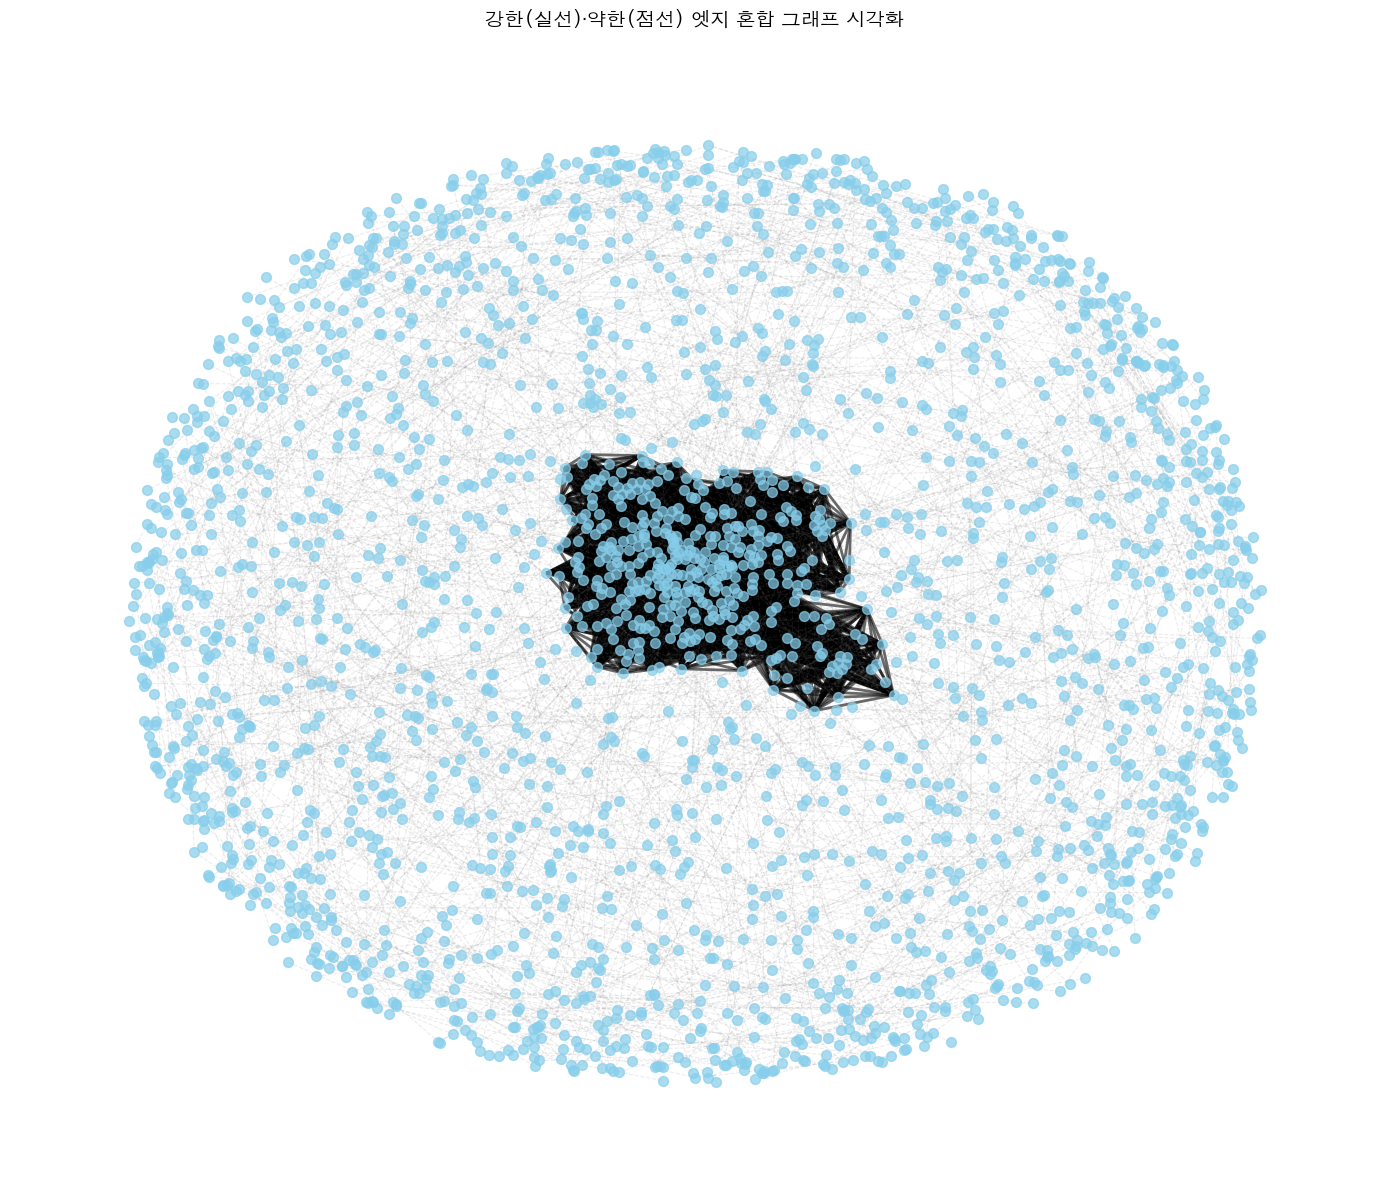

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm

# # --- 1. 한글 폰트 설정 ---
# plt.rcParams['font.family'] = 'AppleGothic'   # Mac
# # plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['axes.unicode_minus'] = False

# # --- 2. 부분 그래프 추출 ---
# sample_size = 2597  # 시각화할 노드 개수
# sample_nodes = random.sample(list(G.nodes), min(sample_size, len(G.nodes)))
# subG = G.subgraph(sample_nodes)

# # --- 3. 레이아웃 계산 (거리 늘리고 반복 횟수 증가) ---
# pos = nx.spring_layout(subG, seed=42, k=0.3, iterations=80)

# # --- 4. 엣지 구분 (가중치 1: 실선 / 1 미만: 점선) ---
# edges_strong = [(u, v) for u, v, d in subG.edges(data=True) if d["weight"] == 1]
# edges_weak = [(u, v) for u, v, d in subG.edges(data=True) if d["weight"] < 1]

# # --- 5. 시각화 ---
# plt.figure(figsize=(14, 12))

# # 강한 엣지 (굵고 선명)
# nx.draw_networkx_edges(subG, pos, edgelist=edges_strong,
#                        width=2.0, edge_color='black', style='solid', alpha=0.6)

# # 약한 엣지 (얇고 반투명)
# nx.draw_networkx_edges(subG, pos, edgelist=edges_weak,
#                        width=0.8, edge_color='gray', style='dashed', alpha=0.15)

# # 노드 (작고 투명하게)
# nx.draw_networkx_nodes(subG, pos, node_color='skyblue', node_size=50, alpha=0.7)

# # 라벨 (너무 많으면 생략 — 필요시 일부만 표시)
# # nx.draw_networkx_labels(subG, pos, font_size=8, font_family='AppleGothic')

# plt.title("강한(실선)·약한(점선) 엣지 혼합 그래프 시각화", fontsize=14, pad=15)
# plt.axis("off")
# plt.tight_layout()
# plt.show()


## 그래프 행렬로 변환 및 add self loops

In [14]:
data = from_networkx(G)
data.edge_weight = data.weight
del data.weight

data.edge_index, data.edge_weight = add_self_loops(
    data.edge_index,
    data.edge_weight,
    fill_value=1.0,
    num_nodes=data.num_nodes
)

data.edge_weight = data.edge_weight.float()

words = list(G.nodes())
data.x = torch.tensor(
    np.stack([G.nodes[n]['features'] for n in G.nodes]), dtype=torch.float
)
print(data)

Data(edge_index=[2, 26517], features=[2597, 384], num_nodes=2597, edge_weight=[26517], x=[2597, 384])


### 메모리 관리

In [15]:
import gc

del df1, df3, edg_info, nod_embed
gc.collect()

5205

## Model

In [16]:
class DMoN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_clusters, num_layers):
        super(DMoN, self).__init__()
        self.num_layers = num_layers

        self.gcn_layers = nn.ModuleList()

        self.gcn_layers.append(GCNConv(input_dim, hidden_dim, add_self_loops=False))

        for _ in range(num_layers - 1):
            self.gcn_layers.append(GCNConv(hidden_dim, hidden_dim, add_self_loops=False))

        self.linear = nn.Linear(hidden_dim, num_clusters)
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x, edge_index, edge_weight=None):
        h = x
        for gcn in self.gcn_layers:
            h = F.selu(gcn(h, edge_index, edge_weight))
        C = F.softmax(self.linear(h) / 1.0, dim=1)
        return C

## Loss

In [17]:
def modularity_loss(C, edge_index, edge_weight, num_nodes):
    """
    Parameters:
    - C: [N, K] soft cluster assignments
    - edge_index: [2, E]
    - edge_weight: [E]
    - num_nodes: int, number of nodes
    """
    src, dst = edge_index #source, destination
    d = torch.zeros(num_nodes, device=C.device)
    d.scatter_add_(0, src, edge_weight)
    d.scatter_add_(0, dst, edge_weight)

    m = edge_weight.sum()

    Ci = C[src]  # [E, K]
    Cj = C[dst]  # [E, K]

    dot = torch.sum(Ci * Cj, dim=1)  # [E]
    expected = (d[src] * d[dst]) / (2 * m + 1e-10)  # [E]
    modularity_terms = edge_weight - expected  # [E]
    Q = torch.sum(dot * modularity_terms) / (2 * m + 1e-10)
    return -Q


def collapse_loss(C):
    n, k = C.size()
    cluster_sizes = C.sum(dim=0)  # [K]
    frob = torch.norm(cluster_sizes, p=2)
    return (frob * (k ** 0.5) / n) - 1.0


def total_loss(C, edge_index, edge_weight, num_nodes, 
               alpha=1.0, beta=0.1):
    mod = modularity_loss(C, edge_index, edge_weight, num_nodes)
    colap = collapse_loss(C)
    return alpha * mod + beta * colap, mod, colap

## RUN!

In [18]:
loss_list = []
mod_list = []
colap_list = []

model = DMoN(input_dim=data.x.size(1), hidden_dim=dim_num, num_clusters=clusters_num, num_layers=layer_num)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

try:
    for epoch in tqdm(range(epochs), desc='Training Epochs'):
        model.train()
        optimizer.zero_grad()
        C = model(data.x, data.edge_index, data.edge_weight)
        loss, mod, colap = total_loss(C, data.edge_index, data.edge_weight, num_nodes=data.num_nodes,
                                      alpha=1.0,
                                      beta=1.0)
        loss.backward()
        optimizer.step()
        
        loss_list.append(loss.item())
        mod_list.append(-mod.item())
        colap_list.append(colap.item())
        
        # print(f"Epoch: {epoch+1}, Loss: {loss.item():.4f}, |Modularity: {-mod.item():.4f}|, Collapse: {colap.item():.4f}")
except KeyboardInterrupt:
    print("\n PAUSED.")

Training Epochs: 100%|██████████| 2000/2000 [01:10<00:00, 28.39it/s]


## 학습 양상

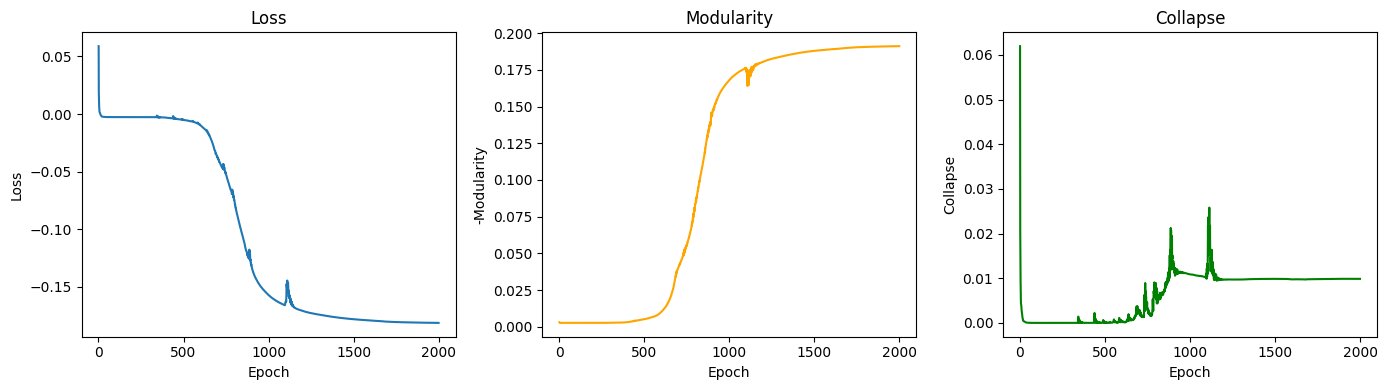

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(loss_list)+1))

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, loss_list, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')

plt.subplot(1, 3, 2)
plt.plot(epochs, mod_list, label='-Modularity', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Modularity')
plt.title('Modularity')

plt.subplot(1, 3, 3)
plt.plot(epochs, colap_list, label='Collapse', color='green')
plt.xlabel('Epoch')
plt.ylabel('Collapse')
plt.title('Collapse')
plt.tight_layout()

if save_or_not is True:
    plt.savefig(f'/Users/kookbab/Desktop/코드_최종_정리/04.exp_output/train_graph/{save_file_name}.png', dpi=1600, bbox_inches='tight')

plt.show()

## Community Detection! - Clustering!

In [20]:
model.eval()
with torch.no_grad():
    C = model(data.x, data.edge_index, data.edge_weight)
    cluster_assignments = C.argmax(dim=1).cpu().numpy()

### 결과 출력

In [21]:
cluster_ids = np.unique(cluster_assignments)
words = np.array(words)

for cid in cluster_ids:
    idxs = np.where(cluster_assignments == cid)[0]
    samples = words[idxs][:50]
    print(f"Cluster {cid}: {', '.join(samples)} (total: {len(idxs)})")

Cluster 0: 캡처, 근간, 저작자, 고객센터, 댓글, 버튜버, 노트, 채택, 메뉴, 프로필, 게이미피케이션, 작문, 스킬, 보편, 유초등, 육박, 블록, 빈도, 칼로, 서비스형, 사진제공 (total: 21)
Cluster 1: 대기업, 부문장, 문제해결, 목록, 조직, 메모, 측정, 지문, 성공사례, 발행, 경영, 출처, 선도적, 영입, 지원단, 개발사, 판매자, 대행, 일반인, 깊이 (total: 20)
Cluster 2: 위험성, 침해, 의학, 스트레스, 부정적, 감각, 바람, 일상적, 통제, 패널, 계정, 공격, 개인별, 취약, 보호, 신속, 예방, 위험, 범위, 촉발, 장치 (total: 21)
Cluster 3: 출간, 차례, 순서, 가정, 재단, 내비게이션, 긍정, 프로덕트, 이수, 부서, 일대일, 적자, 케이크, 리더, 초개인화, 규칙, 이력서, 출판, 근본 (total: 19)
Cluster 4: 모빌리티, 참가, 선수, 임원, 프로그래머, 자리, 이름, 표절, 인터뷰, 공식, 정보기술, 선도, 어학, 직장인들, 전화, 트렌드, 계약, 라이브, 현직, 패러다임 (total: 20)
Cluster 5: 주도적, 위원, 스쿨, 선생님, 관리자, 보조교사, 배움터, 학년, 검토, 사정, 총장, 복수, 현업, 글자, 교과목, 수원, 표시, 원년, 신입, 다차원, 선도학교, 트랙 (total: 22)
Cluster 6: 무료, 문장, 더빙, 자연, 친구, 텍스트, 캐릭터, 체험, 작성, 단어, 메타버스, 버스, 이용, 이미지, 음성, 제작, 스튜디오, 인식, 초등, 대화, 행사, 자유, 아이들, 게임, 영상, 직업, 학습자, 원어민 (total: 28)
Cluster 7: 눈앞, 몸값, 연애, 급증, 플레이, 기분, 조회수, 안보, 백과사전, 분위기, 유로, 드림, 감정, 사흘간, 출범, 사랑, 아티스트, 감성, 웨어러블, 냉장고, 소외 (total: 21)
Cluster 8: 개인적, 필자, 부합, 성인, 기조, 후보, 아바타, 지배, 법령, 

In [22]:
import collections
cnt = collections.Counter(cluster_assignments)
print("클러스터별 노드 수:", cnt)

클러스터별 노드 수: Counter({25: 37, 103: 36, 27: 34, 66: 32, 59: 30, 83: 29, 72: 29, 6: 28, 114: 26, 88: 26, 19: 23, 74: 23, 54: 23, 94: 23, 67: 22, 48: 22, 15: 22, 107: 22, 78: 22, 45: 22, 58: 22, 46: 22, 23: 22, 68: 22, 64: 22, 5: 22, 43: 22, 115: 22, 113: 22, 32: 21, 116: 21, 56: 21, 20: 21, 84: 21, 100: 21, 39: 21, 36: 21, 51: 21, 2: 21, 69: 21, 28: 21, 119: 21, 9: 21, 14: 21, 77: 21, 10: 21, 37: 21, 112: 21, 47: 21, 105: 21, 65: 21, 41: 21, 0: 21, 22: 21, 7: 21, 42: 21, 35: 21, 85: 21, 31: 21, 109: 21, 96: 21, 63: 21, 61: 21, 55: 21, 102: 21, 106: 21, 101: 21, 8: 21, 111: 21, 95: 21, 97: 21, 26: 21, 117: 21, 81: 21, 118: 21, 92: 21, 13: 21, 93: 21, 73: 21, 60: 21, 12: 21, 18: 21, 104: 20, 90: 20, 38: 20, 29: 20, 1: 20, 110: 20, 21: 20, 49: 20, 44: 20, 70: 20, 75: 20, 11: 20, 30: 20, 98: 20, 86: 20, 87: 20, 99: 20, 71: 20, 89: 20, 17: 20, 80: 20, 4: 20, 53: 20, 57: 20, 62: 20, 91: 20, 50: 20, 52: 20, 79: 20, 24: 20, 108: 20, 82: 20, 16: 20, 33: 19, 76: 19, 3: 19, 40: 19, 34: 19})


## Modularity

In [23]:
partition = {word: int(c) for word, c in zip(words, cluster_assignments)}

communities = [
    [w for w, lab in partition.items() if lab == i]
    for i in range(model.linear.out_features)
]

modularity = nx.algorithms.community.modularity(
    G,
    communities,
    weight='weight'
)
print(f"최종 Modularity: {modularity:.4f}")

if save_or_not is True:
    modularity_scores = {"modularity": modularity}
    out_path = f"/Users/kookbab/Desktop/코드_최종_정리/04.exp_output/modularity/{save_file_name}.json"
    with open(out_path, "w") as f:
        json.dump(modularity_scores, f, indent=4)
    print("Modularity scores saved.")

최종 Modularity: 0.3454


## Coherence

In [ ]:
clusters_df = pd.DataFrame({'word': words, 'cluster': cluster_assignments})

communities = defaultdict(list)
for w, c in zip(clusters_df['word'], clusters_df['cluster']):
    communities[c].append(w)

communities_list = [topic_words for topic_words in communities.values()] #  if len(topic_words) >= 1

with open("/tokenized_docs.pkl", "rb") as f:
    tokenized_docs = pickle.load(f)

dictionary = Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(text) for text in tokenized_docs]

coherence_scores = {}
metrics = ['c_v', 'u_mass', 'c_uci', 'c_npmi']

for metric in metrics:
    cm = CoherenceModel(
        topics=communities_list,
        texts=tokenized_docs,
        corpus=corpus if metric == 'u_mass' else None,
        dictionary=dictionary,
        coherence=metric
    )
    coherence_scores[metric] = float(cm.get_coherence())

try:
    w2v_model = Word2Vec(
        tokenized_docs,
        vector_size=100,
        window=5,
        min_count=2,
        workers=1,
        epochs=10,
        seed=RANDOM_STATE
    )
    cm_w2v = CoherenceModel(
        topics=communities_list,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_w2v',
        keyed_vectors=w2v_model.wv
    )
    coherence_scores['c_w2v'] = float(cm_w2v.get_coherence())
except Exception as e:
    print("Word2Vec coherence 계산 실패:", e)
    coherence_scores['c_w2v'] = None

if save_or_not is True:
    output_path = f"/{save_file_name}.json"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(coherence_scores, f, indent=4, ensure_ascii=False)
    print(f"Coherence scores saved to {output_path}")

print(coherence_scores)

{'c_v': 0.5620748311178964, 'u_mass': -12.382117514825335, 'c_uci': -11.604329734986901, 'c_npmi': -0.4049749890475398, 'c_w2v': 0.7220462560653687}


# Topic Naming

In [ ]:
# def build_topic_df(cluster_assignments, words, max_words=None, sort_by="id"):
#     """
#     cluster_assignments: 길이 N의 배열형 (각 단어의 클러스터 ID)
#     words: 길이 N의 단어 리스트/배열
#     max_words: 각 토픽당 출력할 최대 단어 수 (None이면 전부)
#     sort_by: "id"면 클러스터 ID 오름차순, "size"면 클러스터 크기(내림차순) 기준
#     """
#     words = np.asarray(words)
#     cluster_ids = np.unique(cluster_assignments)

#     if sort_by == "size":
#         sizes = {cid: np.sum(cluster_assignments == cid) for cid in cluster_ids}
#         cluster_ids = np.array(sorted(cluster_ids, key=lambda c: (-sizes[c], c)))
#     else:
#         cluster_ids = np.sort(cluster_ids)

#     rows = []
#     for topic_num, cid in enumerate(cluster_ids, start=1):
#         idxs = np.where(cluster_assignments == cid)[0]
#         cluster_words = words[idxs]
#         if max_words is not None:
#             cluster_words = cluster_words[:max_words]
#         rows.append({
#             "Topic": f"Topic {topic_num}",
#             "Words": ", ".join(map(str, cluster_words))
#         })

#     return pd.DataFrame(rows, columns=["Topic", "Words"])

# # 사용 예시:
# df_topics = build_topic_df(cluster_assignments, words, max_words=50, sort_by="id")
# # df_topics.to_csv('/topics_words.csv', index=False)
# df_topics


,Topic,Words
0,Topic 1,"캡처, 근간, 저작자, 고객센터, 댓글, 버튜버, 노트, 채택, 메뉴, 프로필, 게..."
1,Topic 2,"대기업, 부문장, 문제해결, 목록, 조직, 메모, 측정, 지문, 성공사례, 발행, ..."
2,Topic 3,"위험성, 침해, 의학, 스트레스, 부정적, 감각, 바람, 일상적, 통제, 패널, 계..."
3,Topic 4,"출간, 차례, 순서, 가정, 재단, 내비게이션, 긍정, 프로덕트, 이수, 부서, 일..."
4,Topic 5,"모빌리티, 참가, 선수, 임원, 프로그래머, 자리, 이름, 표절, 인터뷰, 공식, ..."
...,...,...
115,Topic 116,"두각, 필수적, 산업현장, 화학, 세미나, 동력, 카테고리, 연구개발, 학계, 수업..."
116,Topic 117,"주민, 지방자치, 주권, 가족들, 절차, 반대, 협의회, 시사, 지혜, 경계, 치수..."
117,Topic 118,"성황리, 탐구, 방향성, 직속, 개방성, 업데이트, 수주, 파트너들, 단독, 전기차..."
118,Topic 119,"교재, 강연, 배치, 지급, 레벨, 문화적, 보상, 저자, 지향, 숫자, 발견, 각..."
